In [20]:
import pandas as pd
import numpy as np
import torch
from clearml import Task
from collections import defaultdict
from matplotlib import pyplot as plt
from scipy.stats import gaussian_kde

In [2]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=ABP1QYAF3E5FG24SDKULXIR2ESEUNL
%env CLEARML_API_SECRET_KEY=EeLEn8EveqxBKL7oBo1-TnIh2gMXw70D-3_EbH57gdVbMrywzLEcBSx_vAzHe-ul45o

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=ABP1QYAF3E5FG24SDKULXIR2ESEUNL
env: CLEARML_API_SECRET_KEY=EeLEn8EveqxBKL7oBo1-TnIh2gMXw70D-3_EbH57gdVbMrywzLEcBSx_vAzHe-ul45o


In [87]:
def select_best(reports):
    res = {}
    for k,v in reports.items():
        #select_val = [m["metrics"]["Summary"]["test_ndcg@20"]["max"] if "Summary" in m["metrics"] else -1 for m in v]
        select_val = []
        for m in v:
            r = -1
            try:
                r = m["metrics"]["Summary"]["test_ndcg@10"]["max"]
                if not "singular_values_seq" in m["artefacts"]:
                    #print("FUCKED")
                    r = -1
                    1/0
            except Exception:
                pass
            select_val.append(r)
            
        select_idx = np.argmax(select_val)
        best = v[select_idx]
        res[k] = best
    return res


def get_max_m(rep):
    metr = rep["metrics"]["Summary"]
    return {k:v["max"] for k,v in metr.items()}
def to_df(reports):
    return pd.DataFrame(
        index = reports.keys(),
        data = [get_max_m(v) for v in reports.values() ]
    )


def calc_impr(df, bt_name):
    df = df.copy()
    imp = df.loc[bt_name]
    for name, row in df.iterrows():
        if name == bt_name:
            continue
        delta = ((imp - row) / row * 100).values
        df.loc[ f"Imp {bt_name} / {name}" ] = delta
    return df

def plot_sing_val_norm(g, mode="seq"):
    for l,v in g.items():
        sv = v["artefacts"][f"singular_values_{mode}"].get()[:64]
        sv = sv / sv.max()
        plt.plot(sv, label=l)
    plt.legend()

def plot_sing_val(g, mode="seq"):
    for l,v in g.items():
        sv = v["artefacts"][f"singular_values_{mode}"].get()[:64]
        plt.plot(sv, label=l)
    plt.legend()

def plot_embeddings_art(g, mode="seq"):
    import umap
    fig, axs = plt.subplots(1,3, figsize=(24, 7), sharey = True, sharex=True)
    

    for i, (k,v) in enumerate(g.items()):
        X_emb = v["artefacts"][f"embeddings_{mode}"].get()
        reducer = umap.UMAP(n_components=2, n_jobs=16)
        X_2d = reducer.fit_transform(X_emb)

        kde = gaussian_kde(X_2d.T)
        density = kde(X_2d.T)
        scatter = axs[i].scatter(X_2d[:, 0], X_2d[:, 1], c=density, s=20, cmap='viridis')
        axs[i].set_title(k)
        plt.colorbar(scatter, ax=axs[i], label='Density')

def average_entropy(logits):
    # Apply softmax to each row for numerical stability
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    
    # Calculate entropy for each row; add a small constant for numerical stability in log
    entropy = -np.sum(probabilities * np.log(probabilities + 1e-12), axis=1)
    
    # Return the average entropy over all rows
    return np.mean(entropy)

def get_avg_entropy(g):
    for i, (k,v) in enumerate(g.items()):
        logits = v["artefacts"]["test_logits"].get()
        entropy = average_entropy(logits)
        print(f"{k}: {entropy:.4f}")
              

def uniformity(origin_z, batch_size, dist="dot"):
    """
    We do not sample negative examples explicitly.
    Instead, given a positive pair, similar to (Chen et al., 2017), we treat the other 2(N − 1) augmented examples within a minibatch as negative examples.
    """

    # pairwise l2 distace
    if dist == 'dot':
        sim = origin_z@origin_z.T
    elif dist == "cos":
        origin_z = origin_z / torch.norm(origin_z, p=2)
        sim = origin_z@origin_z.T
    elif dist == 'l2':
        sim = torch.cdist(origin_z, origin_z, p = 2)
    mask = torch.ones((batch_size, batch_size), dtype=bool)
    mask = mask.fill_diagonal_(0)
    negative_samples = sim[mask].reshape(batch_size, -1)
    uniformity = torch.log(torch.exp(-2 * negative_samples).mean())
    
    return uniformity

def get_uniformity(g, mode="seq", dist="dot"):
    for i, (k,v) in enumerate(g.items()):
        embs = v["artefacts"][f"embeddings_{mode}"].get()
        embs = torch.tensor(embs[:2000])
        unif = uniformity(embs, embs.shape[0], dist=dist)
        print(f"{k}: {unif:.4f}")

def plot_uniformity_vs_ndcg(g):
    for i, (k,v) in enumerate(g.items()):
        print(v.keys())
        unifs = v["scalars"]["Uniformity"]["Val"]["y"]
        ndcgs = v["scalars"]["NDCG"]["Val"]["y"]
        plt.scatter(unifs, ndcgs, label=k)
    plt.xlabel("Uniformity")
    plt.ylabel("NDCG")
    plt.legend()
    plt.show()


In [92]:
#get_uniformity(ml_reports_best, mode="item", dist="l2")
#plot_uniformity_vs_ndcg(yelp_reports_best)

In [4]:
project = "BTSasRec"

In [5]:
#tasks = Task.get_tasks(project_name=project)
d_task_ids = {
    "MovieLens 1M": {
        "BT": "f257ebe1ce8749e1a5fba54b0c59ff3c",
        "FCE": "ba81ff69615046dd867243c47105db2f",
        "SCE": "3b0b07003b7c433ca95139446ccae368",
    },
    "YELP": {
        "BT": "d1787bf27f174ca59ab8975d18bb08f4",
        "FCE": "7a1b8b91e42b4fc1ade15034d79918b6",
        "SCE": "79d31a7ec0524bdca4c0608754319df5"
    },
    "Gowalla": {
        "BT": "7faea67c91fa4d238df04aebcaa9df02",
        "FCE": "85c14515dc2447069e7efb5a94af98ab",
        "SCE": "c98dcaa9fa5646b692df74f814de2cf3"
    }
}
tasks = []
for d, ts in d_task_ids.items():
    for k,v in ts.items():
        tasks.append(v)
tasks = Task.get_tasks(task_ids=tasks)

reports = defaultdict(list)
for t in tasks:
    print(t.name)
    if t.name == "CE Barlow twins":
        continue
    art = {}
    art["scalars"] = t.get_reported_scalars()
    art["metrics"] = t.get_last_scalar_metrics()
    art["parameters"] = t.get_parameters()
    art["artefacts"] = t.artifacts
    reports[t.name].append(art)

ML1M. CE Barlow twins
Full CE
Scalable CE
YELP. CE Barlow twins
YELP. Full CE
YELP. Scalable CE
Gowalla. CE Barlow twins
Gowalla. Full CE
Gowalla. Scalable CE


In [6]:
yelp_reports = {k:v for k,v in reports.items() if 'YELP' in k}
ml_reports = {k:v for k,v in reports.items() if 'YELP' not in k and 'Gowalla' not in k}
gowall_reports = {k:v for k,v in reports.items() if 'Gowalla' in k}

In [7]:
#del ml_reports["CE Barlow twins"]

In [8]:
yelp_reports_best = select_best(yelp_reports)
yelp_metr_df = to_df(yelp_reports_best).filter(regex='^test_')

In [9]:
ml_reports_best = select_best(ml_reports)
ml_metr_df = to_df(ml_reports_best).filter(regex='^test_')



In [10]:
gw_reports_best = select_best(gowall_reports)
gw_metr_df = to_df(gw_reports_best).filter(regex='^test_')

In [11]:
metrics_take = ["test_hr@1", "test_hr@5", "test_hr@10", "test_ndcg@5", "test_ndcg@10", "test_ndcg@50", "test_cov@1", "test_cov@5", "test_cov@10"]
#metrics_take_buckets = [ for m in ["test_hr@1", "test_ndcg@10", "test_cov@10"] ]

## YELP

In [50]:
metr_ye = calc_impr(yelp_metr_df[metrics_take], bt_name = 'YELP. CE Barlow twins')
metr_ye

,test_hr@1,test_hr@5,test_hr@10,test_ndcg@5,test_ndcg@10,test_ndcg@50,test_cov@1,test_cov@5,test_cov@10
YELP. CE Barlow twins,0.004900,0.018300,0.028800,0.011700,0.015000,0.026700,0.021800,0.063600,0.099800
YELP. Full CE,0.001500,0.007300,0.012400,0.004300,0.005900,0.011500,0.000700,0.002500,0.004700
YELP. Scalable CE,0.004000,0.015200,0.027700,0.009700,0.013700,0.025800,0.013500,0.041300,0.066100
Imp YELP. CE Barlow twins / YELP. Full CE,226.666667,150.684932,132.258065,172.093023,154.237288,132.173913,3014.285714,2444.000000,2023.404255
Imp YELP. CE Barlow twins / YELP. Scalable CE,22.500000,20.394737,3.971119,20.618557,9.489051,3.488372,61.481481,53.995157,50.983359


In [194]:
metr_b_ye = yelp_metr_df.filter(regex='test_Bucket_*').filter(regex='hr@1|ndcg@10|cov@10')
calc_impr(metr_b_ye, bt_name = 'YELP. CE Barlow twins').sort_index(axis=1)

,test_Bucket_1 cov@10,test_Bucket_1 hr@1,test_Bucket_1 hr@10,test_Bucket_1 ndcg@10,test_Bucket_2 cov@10,test_Bucket_2 hr@1,test_Bucket_2 hr@10,test_Bucket_2 ndcg@10,test_Bucket_3 cov@10,test_Bucket_3 hr@1,test_Bucket_3 hr@10,test_Bucket_3 ndcg@10
YELP. CE Barlow twins,0.039000,0.018900,0.101900,0.054500,0.054700,0.002900,0.022200,0.010800,0.076000,0.0002,0.001600,0.0008
YELP. Full CE,0.002600,0.007000,0.058800,0.028200,0.003100,0.000000,0.000700,0.000300,0.004100,0.0000,0.000000,0.0000
YELP. Scalable CE,0.027700,0.017300,0.095500,0.050100,0.039100,0.001500,0.022200,0.009400,0.051700,0.0000,0.002100,0.0008
Imp YELP. CE Barlow twins / YELP. Full CE,1400.000000,170.000000,73.299320,93.262411,1664.516129,inf,3071.428571,3500.000000,1753.658537,inf,inf,inf
Imp YELP. CE Barlow twins / YELP. Scalable CE,40.794224,9.248555,6.701571,8.782435,39.897698,93.333333,0.000000,14.893617,47.001934,inf,-23.809524,0.0000


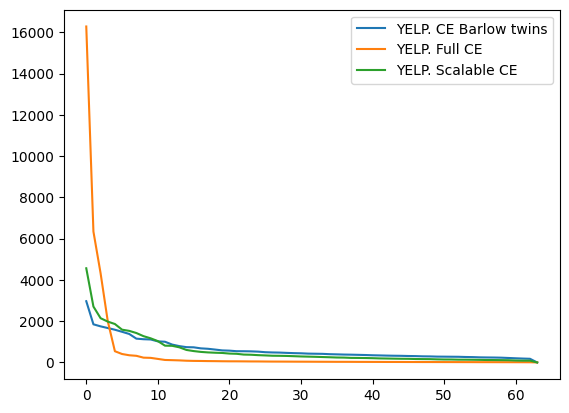

In [47]:
plot_sing_val(yelp_reports_best, mode="logits")

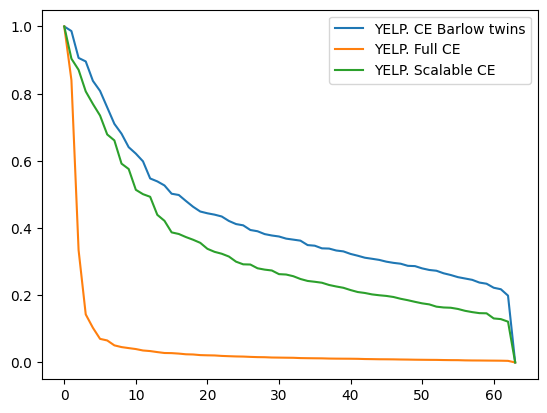

In [37]:
plot_sing_val_norm(yelp_reports_best)

c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting

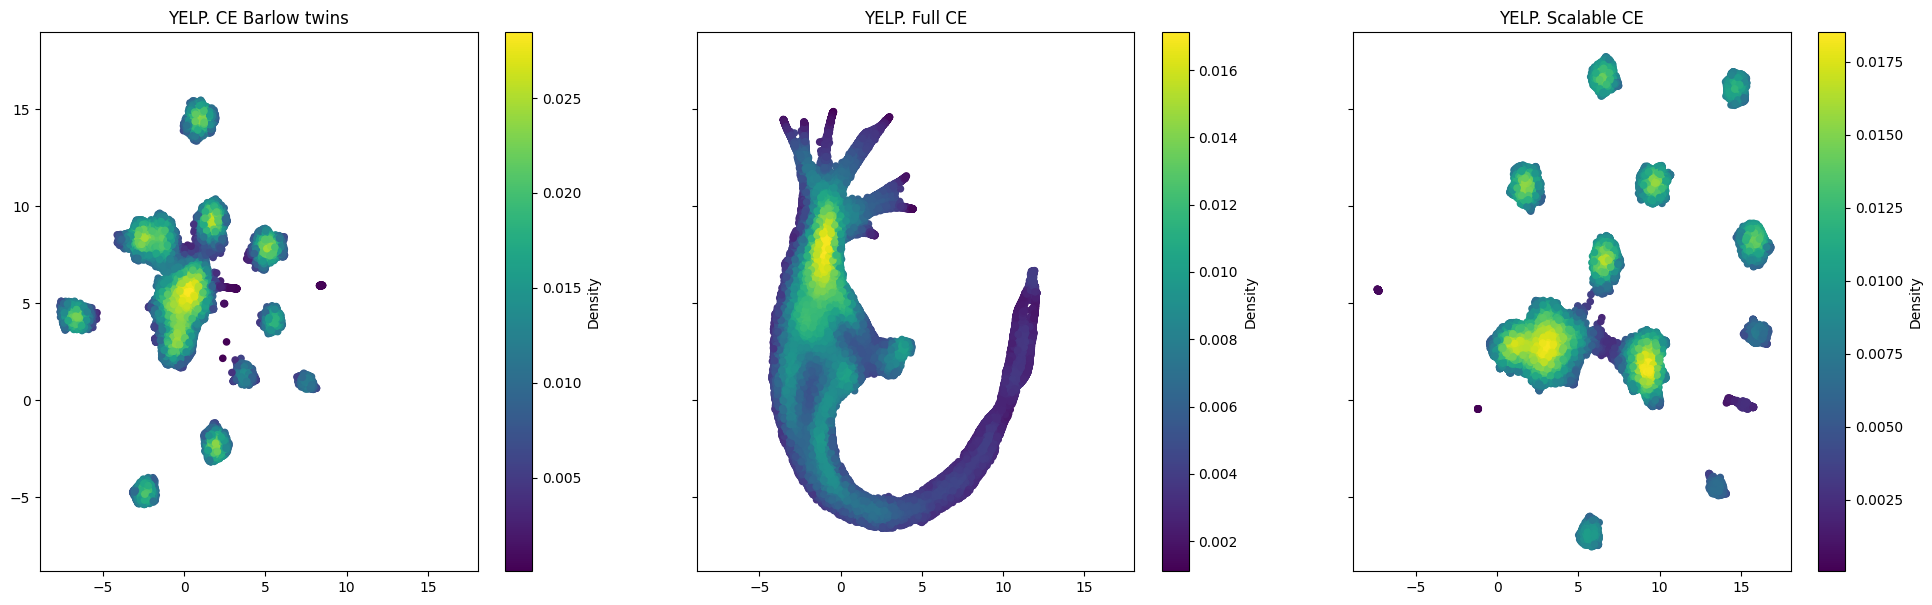

In [15]:
plot_embeddings_art(yelp_reports_best, mode="item")

c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn

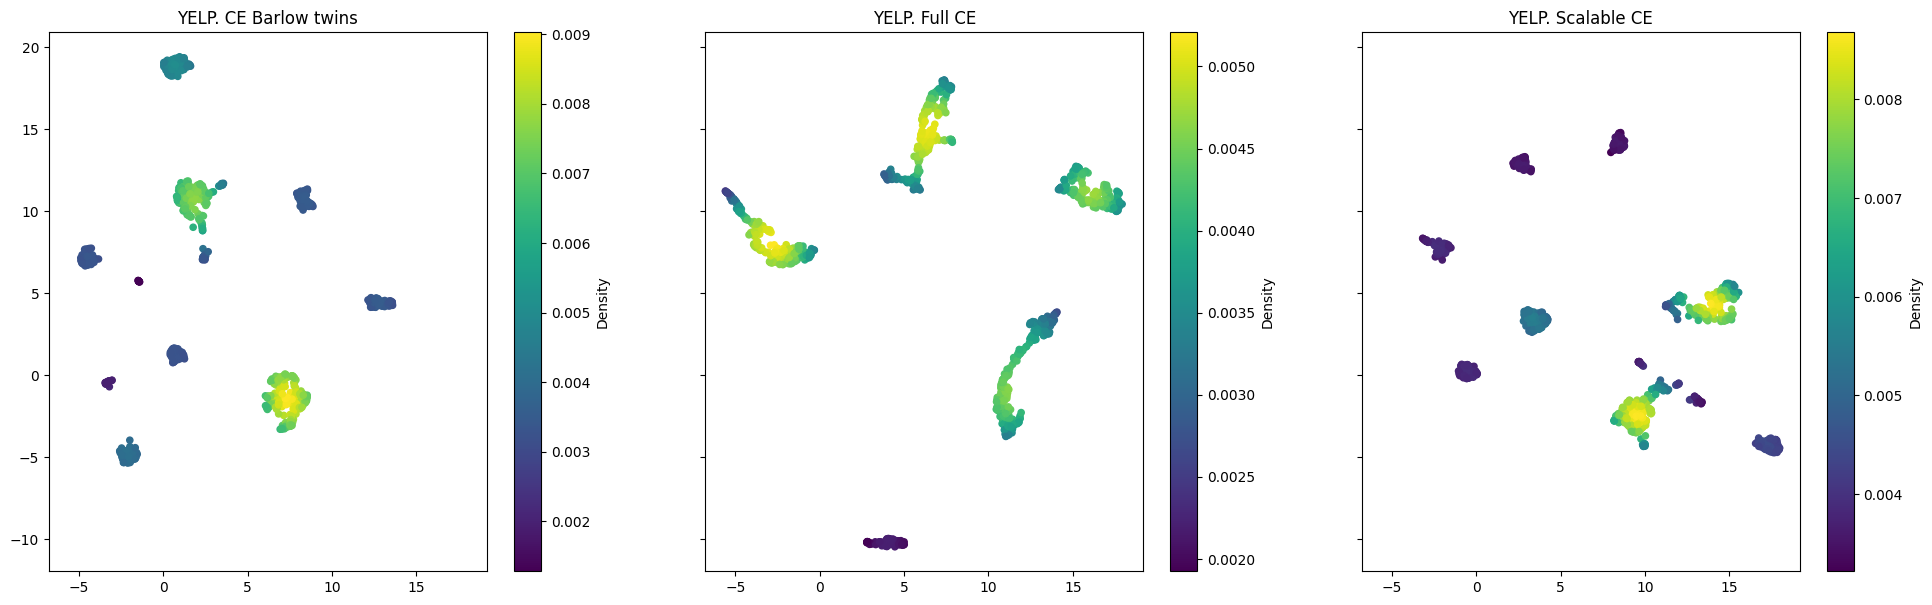

In [16]:
plot_embeddings_art(yelp_reports_best, mode="seq")

dict_keys(['scalars', 'metrics', 'parameters', 'artefacts'])
dict_keys(['scalars', 'metrics', 'parameters', 'artefacts'])
dict_keys(['scalars', 'metrics', 'parameters', 'artefacts'])


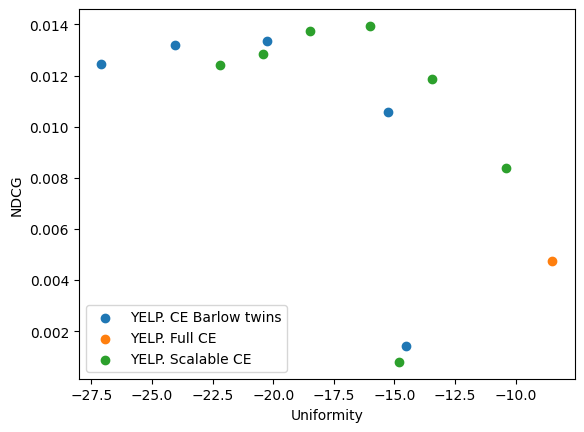

In [94]:
plot_uniformity_vs_ndcg(yelp_reports_best)

## Movielens

In [48]:
metr_ml = calc_impr(ml_metr_df[metrics_take], bt_name = 'ML1M. CE Barlow twins')
metr_ml

,test_hr@1,test_hr@5,test_hr@10,test_ndcg@5,test_ndcg@10,test_ndcg@50,test_cov@1,test_cov@5,test_cov@10
ML1M. CE Barlow twins,0.029300,0.060000,0.098700,0.046100,0.058300,0.087100,0.084900,0.232700,0.324200
Full CE,0.021300,0.060000,0.088000,0.040400,0.049400,0.081800,0.088700,0.226500,0.318500
Scalable CE,0.020000,0.058700,0.093300,0.039300,0.050300,0.080000,0.096100,0.256800,0.364500
Imp ML1M. CE Barlow twins / Full CE,37.558685,0.000000,12.159091,14.108911,18.016194,6.479218,-4.284104,2.737307,1.789639
Imp ML1M. CE Barlow twins / Scalable CE,46.500000,2.214651,5.787781,17.302799,15.904573,8.875000,-11.654527,-9.384735,-11.056241


In [108]:
metr_b_ml = ml_metr_df.filter(regex='test_Bucket_*').filter(regex='hr@1|ndcg@10|cov@10').sort_index(axis=1)
calc_impr(metr_b_ml, bt_name = 'ML1M. CE Barlow twins')

,test_Bucket_1 cov@10,test_Bucket_1 hr@1,test_Bucket_1 hr@10,test_Bucket_1 ndcg@10,test_Bucket_2 cov@10,test_Bucket_2 hr@1,test_Bucket_2 hr@10,test_Bucket_2 ndcg@10,test_Bucket_3 cov@10,test_Bucket_3 hr@1,test_Bucket_3 hr@10,test_Bucket_3 ndcg@10
ML1M. CE Barlow twins,0.151400,0.046200,0.161800,0.097000,0.185400,0.03700,0.106500,0.066800,0.258200,0.0166,0.063700,0.034700
Full CE,0.162700,0.052000,0.150300,0.090000,0.193000,0.01850,0.106500,0.060000,0.257100,0.0083,0.047100,0.023500
Scalable CE,0.176900,0.052000,0.144500,0.088700,0.214700,0.01390,0.092600,0.048100,0.288300,0.0083,0.069300,0.033200
Imp ML1M. CE Barlow twins / Full CE,-6.945298,-11.153846,7.651364,7.777778,-3.937824,100.00000,0.000000,11.333333,0.427849,100.0000,35.244161,47.659574
Imp ML1M. CE Barlow twins / Scalable CE,-14.414924,-11.153846,11.972318,9.357384,-13.646949,166.18705,15.010799,38.877339,-10.440513,100.0000,-8.080808,4.518072


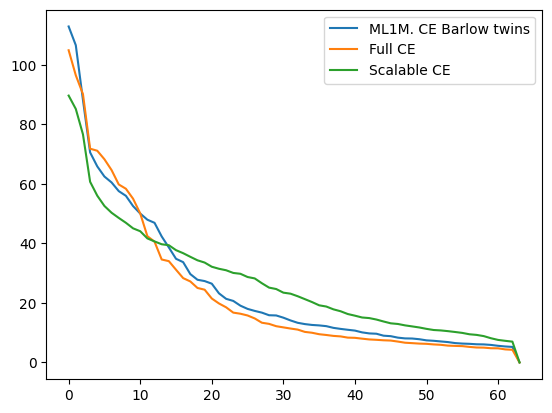

In [97]:
plot_sing_val(ml_reports_best, mode="seq")

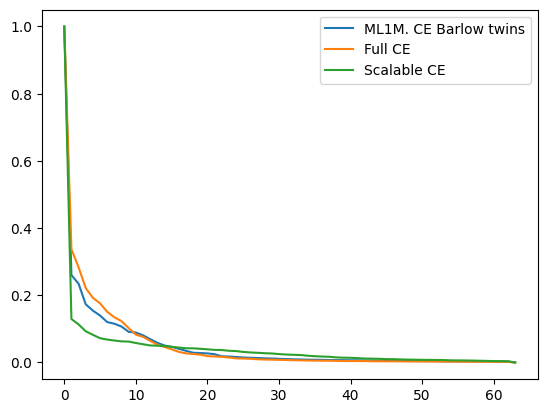

In [189]:
plot_sing_val_norm(ml_reports_best, mode="logits")

c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting

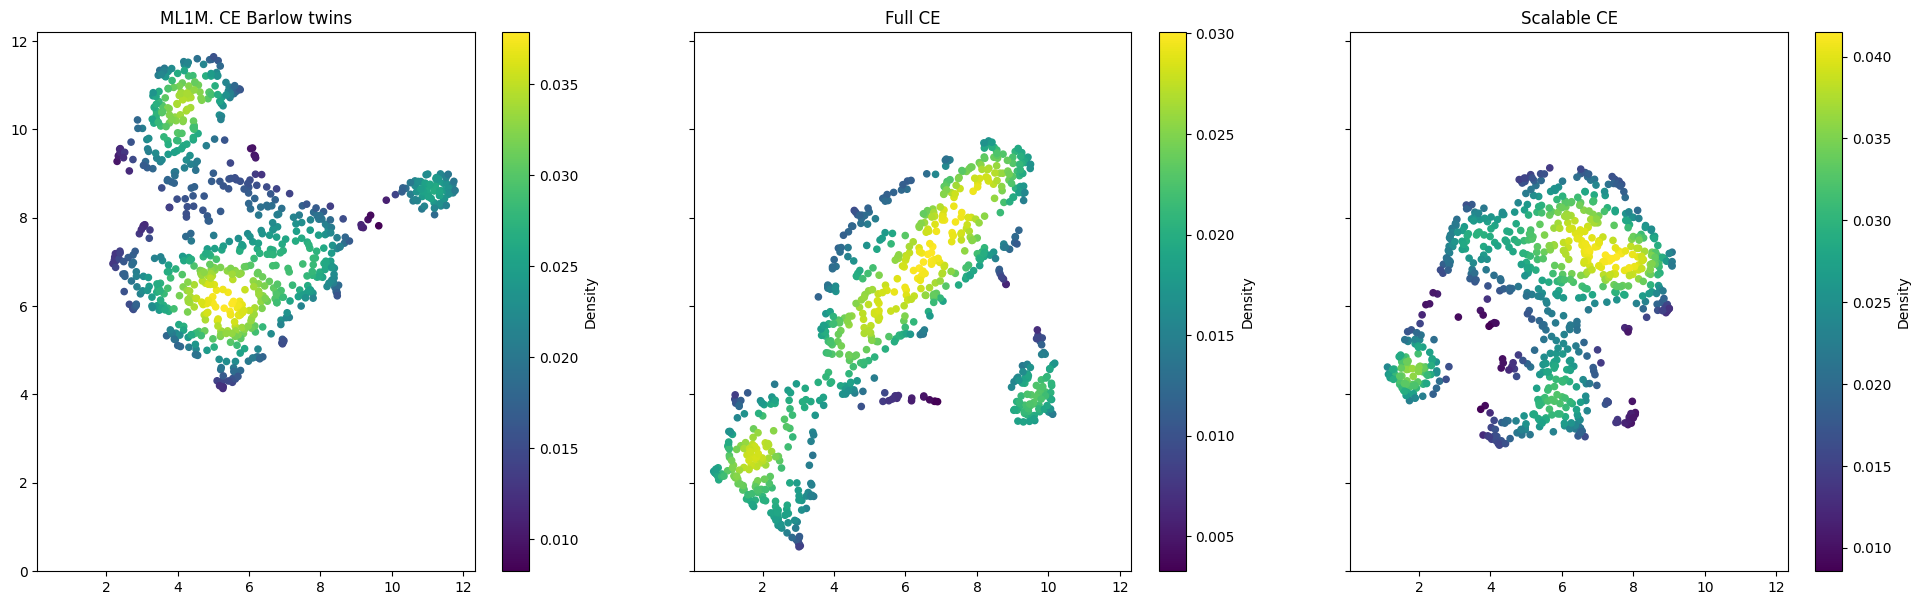

In [22]:
plot_embeddings_art(ml_reports_best)

c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn

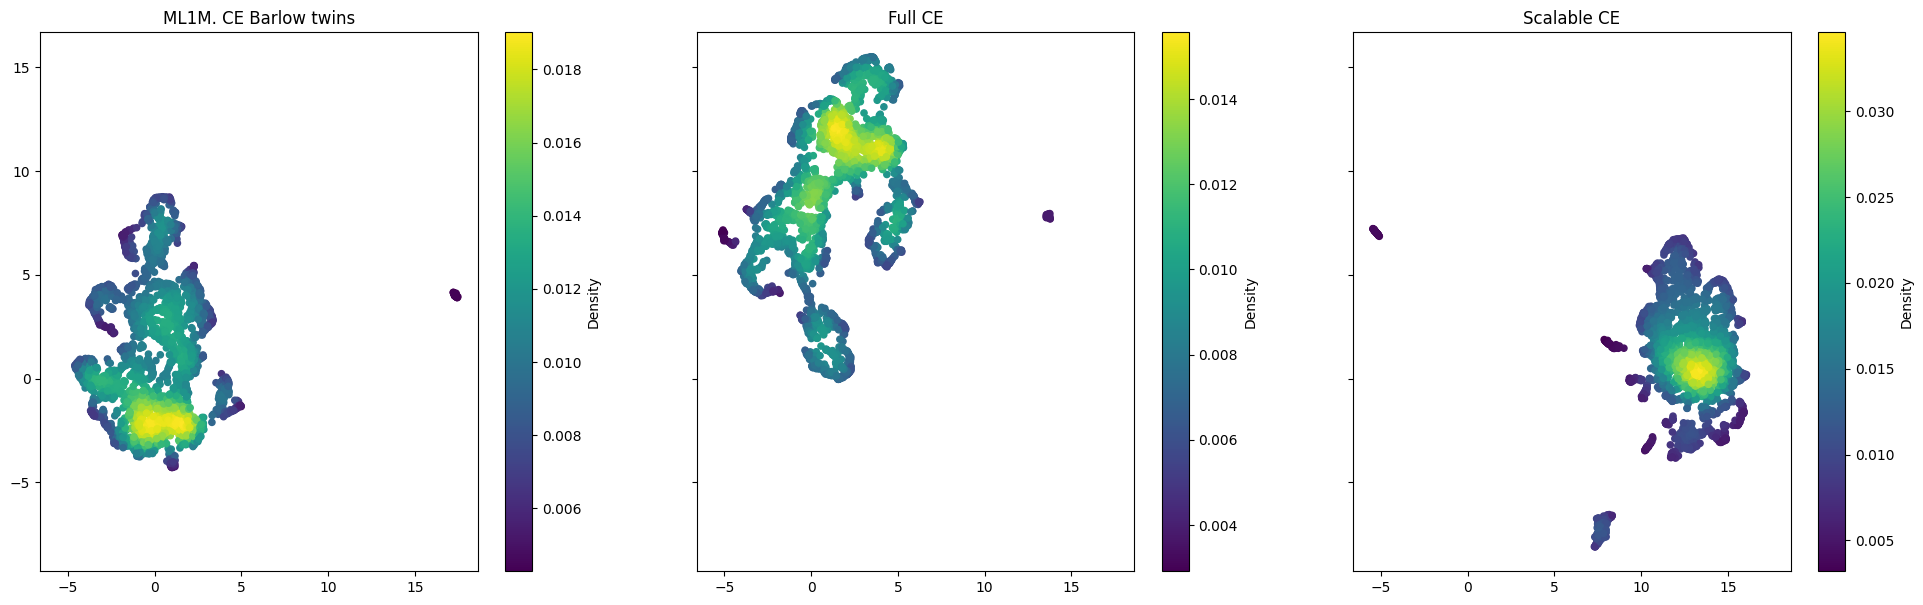

In [17]:
plot_embeddings_art(ml_reports_best, mode="item")

## Gowalla

In [49]:
metr_gw = calc_impr(gw_metr_df[metrics_take], bt_name = 'Gowalla. CE Barlow twins')

In [190]:
metr_b_gw = gw_metr_df.filter(regex='test_Bucket_*').filter(regex='hr@1$|ndcg@10|ndcg@50|cov@10').sort_index(axis=1)
calc_impr(metr_b_gw, bt_name = 'Gowalla. CE Barlow twins')

,test_Bucket_1 cov@10,test_Bucket_1 hr@1,test_Bucket_1 ndcg@10,test_Bucket_1 ndcg@50,test_Bucket_2 cov@10,test_Bucket_2 hr@1,test_Bucket_2 ndcg@10,test_Bucket_2 ndcg@50,test_Bucket_3 cov@10,test_Bucket_3 hr@1,test_Bucket_3 ndcg@10,test_Bucket_3 ndcg@50
Gowalla. CE Barlow twins,0.075200,0.042200,0.087000,0.111600,0.082000,0.013200,0.041300,0.061400,0.147000,0.009300,0.025300,0.038400
Gowalla. Full CE,0.048900,0.034400,0.084000,0.116100,0.056100,0.012300,0.031800,0.050200,0.084400,0.001400,0.005800,0.010600
Gowalla. Scalable CE,0.055400,0.045300,0.093300,0.122400,0.063000,0.009600,0.033200,0.052500,0.113400,0.007000,0.019300,0.029600
Imp Gowalla. CE Barlow twins / Gowalla. Full CE,53.783231,22.674419,3.571429,-3.875969,46.167558,7.317073,29.874214,22.310757,74.170616,564.285714,336.206897,262.264151
Imp Gowalla. CE Barlow twins / Gowalla. Scalable CE,35.740072,-6.843267,-6.752412,-8.823529,30.158730,37.500000,24.397590,16.952381,29.629630,32.857143,31.088083,29.729730


c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn

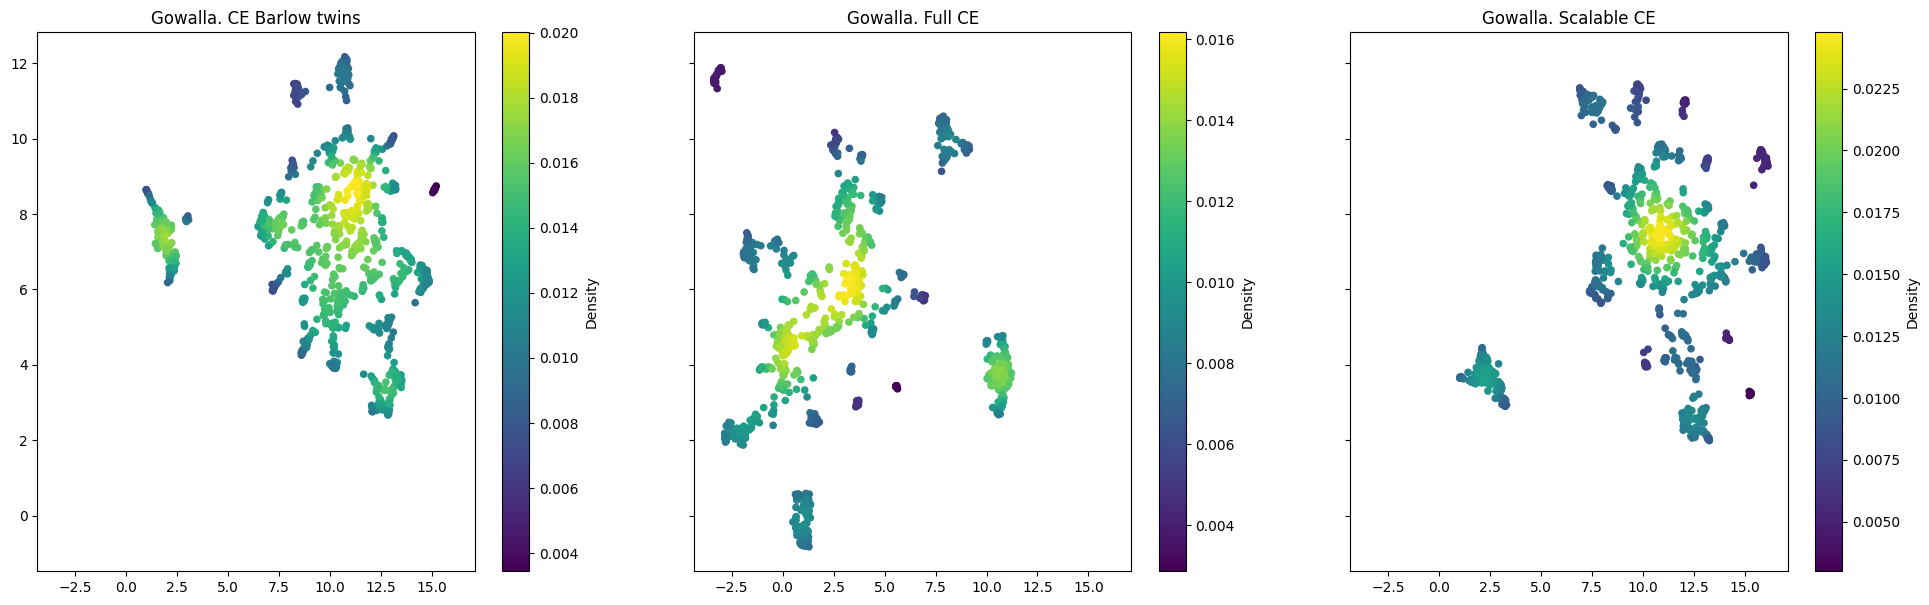

In [44]:
plot_embeddings_art(gw_reports_best)

c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


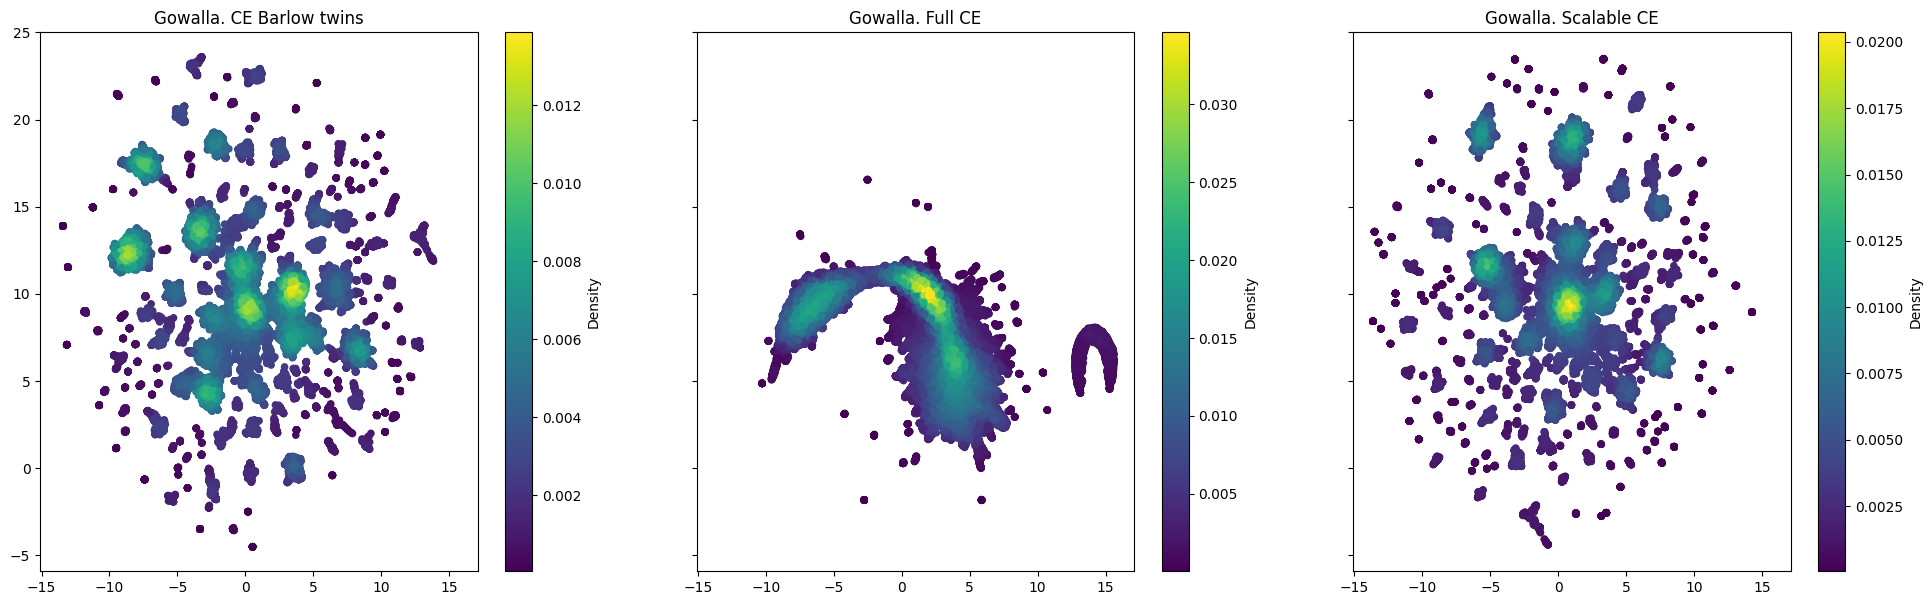

In [12]:
plot_embeddings_art(gw_reports_best, mode="item")

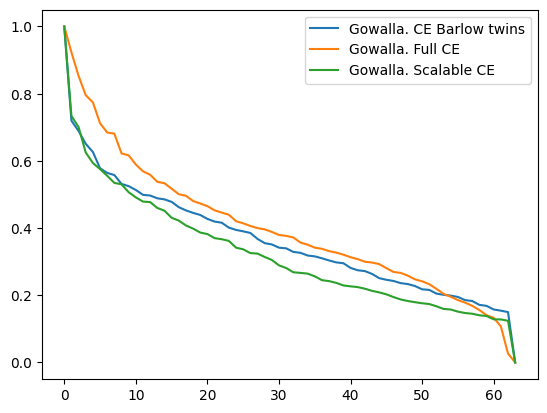

In [100]:
plot_sing_val_norm(gw_reports_best, mode="seq")

## To markdown

In [103]:
import re

def rename_cols(df, dataset, names = ["CE Barlow twins", "Full CE", "Scalable CE"]):
    rename_dict = {}
    improve_counter = 1

    for col in df.columns:
        matched = False
        if '/' in col:
            rename_dict[col] = f'improve{improve_counter}'
            improve_counter += 1
        else:
            for name in names:
                # Check if column ends exactly with ". {name}" (spaces allowed)
                if re.match(rf'^.*\.\s*{re.escape(name)}$', col):
                    rename_dict[col] = name
                    matched = True
                    break  # Found a match, stop checking further names

    df = df.rename(columns=rename_dict)
    df.index = [s.replace("test_", "") for s in df.index.tolist()]

    df = df.drop(["improve1", "improve2"], axis=1)

    df.index = pd.MultiIndex.from_arrays(
        [[dataset]*df.shape[0], df.index]
    )

    df = df[["Full CE", "Scalable CE", "CE Barlow twins"]]

    max_df = df[["Full CE", "Scalable CE"]].max(axis=1)
    df["Improve"] = ((df["CE Barlow twins"] - max_df) / max_df * 100).round(1)
    df["Improve"] = df["Improve"].apply(lambda x: ("+" + str(x) if str(x)[0] != "-" else str(x)) + "%")

    return df

main_metrics = pd.concat([
    rename_cols(metr_ml.T, dataset="ML 1M"),
    rename_cols(metr_ye.T, dataset="YELP"),
    rename_cols(metr_gw.T, dataset="Gowalla"),
])

In [105]:
print(main_metrics.to_latex())

\begin{tabular}{llrrrl}
\toprule
 &  & Full CE & Scalable CE & CE Barlow twins & Improve \\
\midrule
\multirow[t]{9}{*}{ML 1M} & hr@1 & 0.021300 & 0.020000 & 0.029300 & +37.6% \\
 & hr@5 & 0.060000 & 0.058700 & 0.060000 & +0.0% \\
 & hr@10 & 0.088000 & 0.093300 & 0.098700 & +5.8% \\
 & ndcg@5 & 0.040400 & 0.039300 & 0.046100 & +14.1% \\
 & ndcg@10 & 0.049400 & 0.050300 & 0.058300 & +15.9% \\
 & ndcg@50 & 0.081800 & 0.080000 & 0.087100 & +6.5% \\
 & cov@1 & 0.088700 & 0.096100 & 0.084900 & -11.7% \\
 & cov@5 & 0.226500 & 0.256800 & 0.232700 & -9.4% \\
 & cov@10 & 0.318500 & 0.364500 & 0.324200 & -11.1% \\
\cline{1-6}
\multirow[t]{9}{*}{YELP} & hr@1 & 0.001500 & 0.004000 & 0.004900 & +22.5% \\
 & hr@5 & 0.007300 & 0.015200 & 0.018300 & +20.4% \\
 & hr@10 & 0.012400 & 0.027700 & 0.028800 & +4.0% \\
 & ndcg@5 & 0.004300 & 0.009700 & 0.011700 & +20.6% \\
 & ndcg@10 & 0.005900 & 0.013700 & 0.015000 & +9.5% \\
 & ndcg@50 & 0.011500 & 0.025800 & 0.026700 & +3.5% \\
 & cov@1 & 0.000700 & 0.0135

In [215]:
def plot_two_metrics(df, dataset_name, metrics_to_plot):
    """
    Create a grouped bar chart for a single dataset (df),
    comparing two selected metrics across all models (df.index).
    """
    models = df.index
    n_models = len(models)
    buckets = ["1", "2", "3"]
    x_positions = np.arange(len(buckets))  # positions for each model on the x-axis

    # Bar width (tweak as needed)
    bar_width = 0.2

    # Create a new figure and axis (one plot per call)
    fig, ax = plt.subplots(figsize=(4, 3))

    print(models)

    for i, model in enumerate(models):
        # Plot the first metric slightly to the left
        ax.bar(
            x_positions + bar_width*i - bar_width * 1,
            df.loc[model, [f"test_Bucket_{b} "+metrics_to_plot[0] for b in range(1,4)]].tolist(),
            bar_width,
            label=model
        )

        """ax.bar(
            x_positions + bar_width*i + bar_width * 0.2,
            df.loc[model, [f"test_Bucket_{b} "+metrics_to_plot[1] for b in range(1,4)]].tolist(),
            bar_width,
            label=model
        )"""

    # Set axis labels and title
    ax.set_xticks(x_positions)
    ax.set_xticklabels(buckets)
    ax.set_ylabel(metrics_to_plot[0])  # Or whatever y-axis label makes sense
    ax.set_xlabel("Bucket")
    ax.set_title(dataset_name)
    ax.legend()

    # Show the plot (one figure per dataset)
    #plt.show()

def rename_index(df, names = ["CE Barlow twins", "Full CE", "Scalable CE"]):
    rename_dict = {}
    improve_counter = 1

    for col in df.index:
        matched = False
        if '/' in col:
            rename_dict[col] = f'improve{improve_counter}'
            improve_counter += 1
        else:
            for name in names:
                # Check if column ends exactly with ". {name}" (spaces allowed)
                if re.match(rf'^.*\.\s*{re.escape(name)}$', col):
                    rename_dict[col] = name
                    matched = True
                    break  # Found a match, stop checking further names

    df = df.rename(index=rename_dict)

    return df

Index(['CE Barlow twins', 'Full CE', 'Scalable CE'], dtype='object')


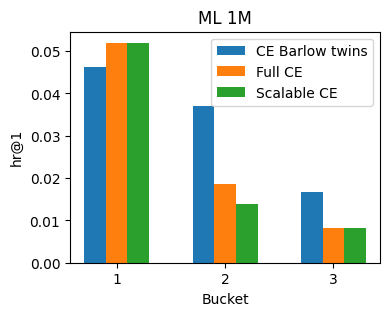

In [216]:
plot_two_metrics(rename_index(metr_b_ml), "ML 1M", ["hr@1", "ndcg@10"] )
plt.savefig("./plots/bucket_metrics/ml.png")

Index(['CE Barlow twins', 'Full CE', 'Scalable CE'], dtype='object')


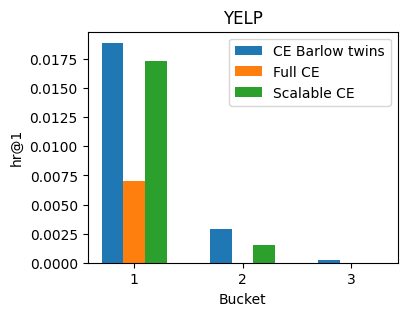

In [217]:
plot_two_metrics(rename_index(metr_b_ye), "YELP", ["hr@1", "ndcg@10"] )
plt.savefig("./plots/bucket_metrics/yelp.png")

Index(['CE Barlow twins', 'Full CE', 'Scalable CE'], dtype='object')


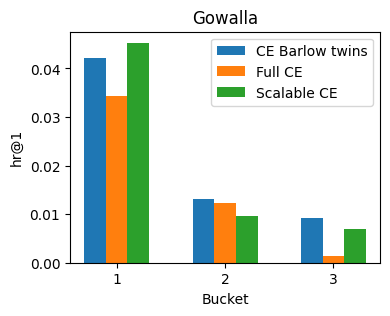

In [218]:
plot_two_metrics(rename_index(metr_b_gw), "Gowalla", ["hr@1", "ndcg@10"] )
plt.savefig("./plots/bucket_metrics/gowalla.png")